<a href="https://colab.research.google.com/github/MHFAHAT/CNN_22-47348-2-CVPR/blob/main/CNN_22_47348_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Preparation & Loading

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Define the Base Path
# Based on your structure: Google Drive -> ML -> Cherry
base_path = '/content/drive/MyDrive/ML/Cherry'

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 3. Hyperparameters
batch_size = 32
learning_rate = 1e-3
epochs = 15

# 4. Transformations (Preprocessing & Augmentation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 5. Load Datasets using ImageFolder
# This points to the individual subfolders you listed
train_dataset = datasets.ImageFolder(root=os.path.join(base_path, 'train'), transform=transform)
valid_dataset = datasets.ImageFolder(root=os.path.join(base_path, 'valid'), transform=transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(base_path, 'test'),  transform=transform)

# 6. Data Loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

num_classes = len(train_dataset.classes)

# Debugging: Check if images loaded correctly
print(f"Classes: {train_dataset.classes}")
print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(valid_dataset)}")
print(f"Test size: {len(test_dataset)}")

Mounted at /content/drive
Classes: ['Cherry Leaf Scorch', 'Cherry Normal leaf', 'Cherry brown_spot', 'Cherry purple leaf spot', 'Cherry_shot hole disease']
Train size: 4042
Valid size: 466
Test size: 999


---

### 2. CNN Architecture



In [2]:
class CherryCNN(nn.Module):
    def __init__(self, num_classes):
        super(CherryCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CherryCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

---

### 3. Training Loop

This will track both accuracy and loss for your final curves.

In [3]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss, correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    # Validation/Test phase
    model.eval()
    test_loss, test_correct = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_correct += predicted.eq(labels).sum().item()

    # Metrics
    train_acc = 100. * correct / len(train_loader.dataset)
    test_acc = 100. * test_correct / len(test_loader.dataset)

    history['train_loss'].append(train_loss/len(train_loader))
    history['test_loss'].append(test_loss/len(test_loader))
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    scheduler.step(test_loss)
    print(f'Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%')

# Save Model
torch.save(model.state_dict(), 'CNN_22-47348-2.pth')

Epoch 1: Train Acc: 68.18% | Test Acc: 87.09%
Epoch 2: Train Acc: 79.19% | Test Acc: 88.19%
Epoch 3: Train Acc: 83.47% | Test Acc: 88.39%
Epoch 4: Train Acc: 85.40% | Test Acc: 92.99%
Epoch 5: Train Acc: 86.79% | Test Acc: 94.09%
Epoch 6: Train Acc: 87.70% | Test Acc: 92.59%
Epoch 7: Train Acc: 88.94% | Test Acc: 91.99%
Epoch 8: Train Acc: 87.83% | Test Acc: 94.49%
Epoch 9: Train Acc: 90.57% | Test Acc: 96.10%
Epoch 10: Train Acc: 90.57% | Test Acc: 96.80%
Epoch 11: Train Acc: 91.44% | Test Acc: 96.60%
Epoch 12: Train Acc: 91.71% | Test Acc: 97.30%
Epoch 13: Train Acc: 90.70% | Test Acc: 96.40%
Epoch 14: Train Acc: 90.70% | Test Acc: 95.20%
Epoch 15: Train Acc: 92.18% | Test Acc: 97.70%


---

### 4. Evaluation & Visualizations

To fill out your form, you need a confusion matrix and a classification report.

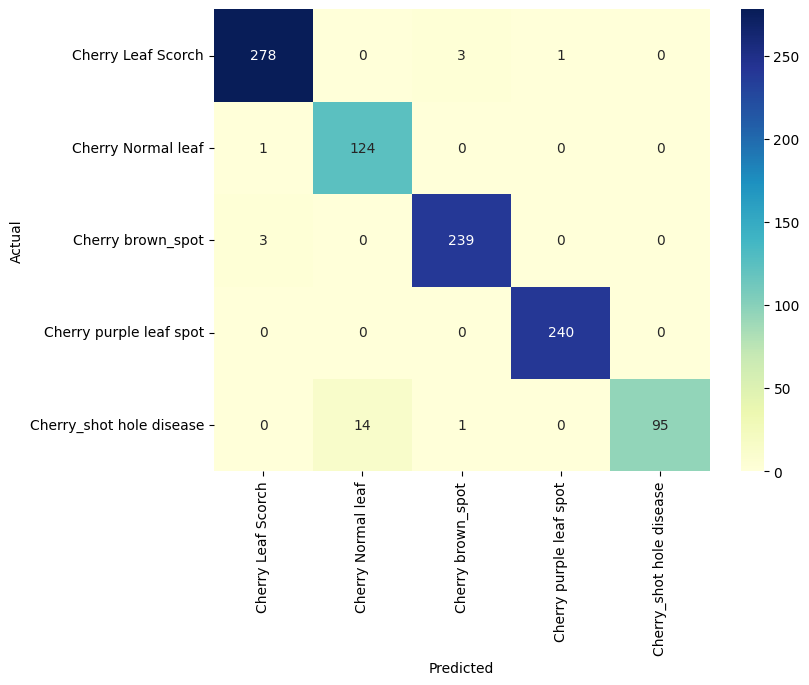

                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.99      0.99      0.99       282
      Cherry Normal leaf       0.90      0.99      0.94       125
       Cherry brown_spot       0.98      0.99      0.99       242
 Cherry purple leaf spot       1.00      1.00      1.00       240
Cherry_shot hole disease       1.00      0.86      0.93       110

                accuracy                           0.98       999
               macro avg       0.97      0.97      0.97       999
            weighted avg       0.98      0.98      0.98       999



In [6]:
# Confusion Matrix
y_pred, y_true = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

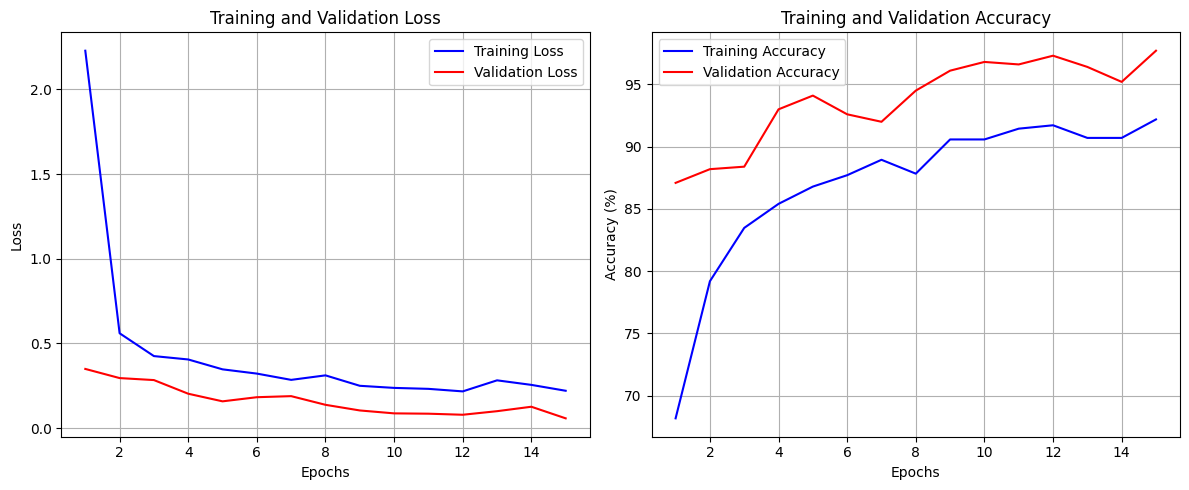

In [7]:
import matplotlib.pyplot as plt

# Define the number of epochs for the x-axis
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# 1. Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Training Loss')
plt.plot(epochs_range, history['test_loss'], 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-', label='Training Accuracy')
plt.plot(epochs_range, history['test_acc'], 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()